# Sionna RT Scenario Visualization

This notebook visualizes all scenarios defined in `heatmap_situations.py`, showing:
- Building positions and geometry
- Transmitter location (red)
- RIS points (blue)
- Receiver locations (green)
- Propagation paths (rays) between actors

Each scenario is loaded from its corresponding XML file in `mesh_scene/` and rendered with Sionna RT.

## Setup and Imports

In [ ]:
import os
import numpy as np
import pandas as pd
from IPython.display import display

# Import Sionna RT components
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, mi

# Import situation definitions
from heatmap_situations import situations
from sionna_utils import create_tx_actor, create_ris_actor, create_rx_actor

# Parameters matching compute_sionna_channels.py
K = 4   # Number of antennas (TX/RX)
N = 36  # Number of RIS elements

navigable_preview = False

print("✓ Imports successful")
print(f"  K (antennas): {K} → {int(np.sqrt(K))}×{int(np.sqrt(K))} arrays")
print(f"  N (RIS elements): {N} → {int(np.sqrt(N))}×{int(np.sqrt(N))} arrays")

## Visualization Function

In [ ]:
def visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256):
    """
    Visualize a single scenario with buildings, actors, and propagation paths.
    
    This version shows paths from:
    - TX → RIS points
    - TX → Receivers
    - RIS → other RIS points (if visible)
    - RIS → Receivers
    
    Paths crossing buildings are automatically filtered out.
    Now uses the same orientations and array sizes as compute_sionna_channels.py
    
    Args:
        situation: Situation dictionary from heatmap_situations.py
        render_resolution: Tuple of (width, height) for rendered image
        num_samples: Number of samples for ray tracing (higher = better quality)
    """
    simulation_name = situation['simulation_name']
    scene_path = f"mesh_scene/{simulation_name}.xml"
    
    if not os.path.exists(scene_path):
        print(f"❌ Error: Scene file not found: {scene_path}")
        return
    
    print(f"\n{'='*60}")
    print(f"{simulation_name}")
    print(f"{'='*60}")
    print(f"Scene: {situation['width']}m × {situation['height']}m | "
          f"Buildings: {len(situation['buildings'])} | "
          f"RIS: {len(situation['ris_points'])} | "
          f"Receivers: {len(situation['receivers'])}")
    
    # Load scene
    scene = load_scene(scene_path)
    scene.frequency = 3.5e9
    
    # Get scenario data
    tx_point = situation['transmitter']
    ris_points = situation['ris_points']
    receivers = situation['receivers']
    buildings = situation['buildings']
    
    # Create Actor objects using helper functions from sionna_utils
    # This ensures the same orientations as compute_sionna_channels.py
    tx_actor = create_tx_actor(tx_point, ris_points, receivers, K)
    
    ris_actors = []
    for i, ris_point in enumerate(ris_points):
        ris_actor = create_ris_actor(f'P{i+1}', ris_point, tx_point, receivers, N)
        ris_actors.append(ris_actor)
    
    rx_actors = []
    for i, receiver in enumerate(receivers):
        rx_actor = create_rx_actor(f'R{i+1}', receiver, ris_points, tx_point, K)
        rx_actors.append(rx_actor)
    
    print(f"\n🔍 Actor Configuration:")
    print(f"  TX: position={tx_actor.position}, orientation={tx_actor.orientation}, array={tx_actor.rows}×{tx_actor.cols}")
    for ris_actor in ris_actors:
        print(f"  {ris_actor.name}: position={ris_actor.position}, orientation={ris_actor.orientation}, array={ris_actor.rows}×{ris_actor.cols}")
    for rx_actor in rx_actors:
        print(f"  {rx_actor.name}: position={rx_actor.position}, orientation={rx_actor.orientation}, array={rx_actor.rows}×{rx_actor.cols}")
    
    # Configure antenna arrays dynamically based on actor type
    # TX and RX use K×K arrays (e.g., 2×2 for K=4)
    scene.tx_array = PlanarArray(
        num_rows=int(np.sqrt(K)),
        num_cols=int(np.sqrt(K)),
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    scene.rx_array = PlanarArray(
        num_rows=int(np.sqrt(K)),
        num_cols=int(np.sqrt(K)),
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    # Add visual markers with proper orientations
    # Transmitter (RED)
    tx = Transmitter(
        name=tx_actor.name,
        position=mi.Point3f(list(tx_actor.position)),
        orientation=mi.Point3f(list(tx_actor.orientation)),
        display_radius=0.5,
        color=[1.0, 0.0, 0.0]  # Red
    )
    scene.add(tx)
    print(f"\n  ✓ Added TX as transmitter at {tx_actor.position} with orientation {tx_actor.orientation}")
    
    # RIS Points (BLUE) - Add as TRANSMITTERS to compute paths FROM them
    # Note: RIS uses N×N arrays in reality, but Sionna doesn't support per-actor array config
    # The arrays will be K×K for visualization, but orientations are correct
    for ris_actor in ris_actors:
        ris = Transmitter(
            name=ris_actor.name,
            position=mi.Point3f(list(ris_actor.position)),
            orientation=mi.Point3f(list(ris_actor.orientation)),
            display_radius=0.4,
            color=[0.0, 0.0, 1.0]  # Blue
        )
        scene.add(ris)
        print(f"  ✓ Added {ris_actor.name} as transmitter at {ris_actor.position} with orientation {ris_actor.orientation}")
    
    # RIS Points - Also add as RECEIVERS to receive paths (TX→RIS, RIS→RIS)
    # This dual role allows visualization of all propagation paths
    for ris_actor in ris_actors:
        ris_rx = Receiver(
            name=f"{ris_actor.name}_rx",
            position=mi.Point3f(list(ris_actor.position)),
            orientation=mi.Point3f(list(ris_actor.orientation)),
            display_radius=0.0,  # Hidden, just for path computation
            color=[0.0, 0.0, 1.0]
        )
        scene.add(ris_rx)
        print(f"  ✓ Added {ris_actor.name}_rx as receiver (for showing TX→RIS and RIS→RIS paths)")
    
    # Receivers (GREEN)
    for rx_actor in rx_actors:
        rx = Receiver(
            name=rx_actor.name,
            position=mi.Point3f(list(rx_actor.position)),
            orientation=mi.Point3f(list(rx_actor.orientation)),
            display_radius=0.3,
            color=[0.0, 1.0, 0.0]  # Green
        )
        scene.add(rx)
        print(f"  ✓ Added {rx_actor.name} as receiver at {rx_actor.position} with orientation {rx_actor.orientation}")
    
    # Setup camera position
    center_x = situation['width'] / 2
    center_y = situation['height'] / 2
    max_dim = max(situation['width'], situation['height'])

    camera_height = max_dim * 2
    camera_offset = max_dim * 0.15
    look_at_height = 5.0

    camera = Camera(
        position=mi.Point3f([center_x - camera_offset, center_y - camera_offset, camera_height]),
        look_at=mi.Point3f([center_x, center_y, look_at_height])
    )
    
    # Compute propagation paths - Single PathSolver call with all transmitters
    # RIS points appear as both transmitters and receivers to show all paths:
    #   - TX → RIS (via RIS as receiver)
    #   - RIS → RIS (via RIS as both transmitter and receiver)
    #   - RIS → RX (via RIS as transmitter)
    try:
        print(f"\n🔄 Running PathSolver with {1 + len(ris_actors)} transmitters and {len(ris_actors) + len(rx_actors)} receivers...")
        print(f"   Transmitters: {tx_actor.name}, {', '.join([a.name for a in ris_actors])}")
        print(f"   Receivers: {', '.join([f'{a.name}_rx' for a in ris_actors])} {', '.join([a.name for a in rx_actors])}")
        print(f"   Note: RIS added as BOTH transmitter and receiver to show all path combinations")
        
        path_solver = PathSolver()
        
        # Keep synthetic_array=True for visualization (shows all paths together)
        paths = path_solver(
            scene=scene,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=False,
            refraction=True,
            synthetic_array=True,  # True for visualization (differs from compute file)
            seed=42
        )
        
        print(f"  ✅ PathSolver completed!")
        
        # Render scene with all paths
        print(f"\n🎨 Rendering scene with all paths...")
        
        if not navigable_preview:
            scene.render(
                camera=camera,
                paths=paths,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✅ Complete\n")
        
    except Exception as e:
        print(f"❌ ERROR computing/rendering paths: {e}")
        import traceback
        traceback.print_exc()
        print("\nRendering without paths...")
        
        # Render without paths
        if not navigable_preview:
            scene.render(
                camera=camera,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✓ Complete\n")

print("✓ Visualization function loaded")
print("  Now uses calculated orientations matching compute_sionna_channels.py")
print("  TX/RX arrays: √K×√K, RIS orientation calculated as bisector angle")
print("  RIS added as BOTH transmitter and receiver to visualize all paths")

## Visualize All Scenarios

The following cell will visualize each scenario in the situations list.

**Color Legend:**
- 🔴 **Red sphere** = Transmitter (TX)
- 🔵 **Blue spheres** = RIS Points (RIS1, RIS2, ...)
- 🟢 **Green spheres** = Receivers (RX1, RX2, ...)
- **Colored rays** = Propagation paths

SCENARIO VISUALIZATION

Found 5 scenarios to visualize


[1/5]

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 3, 'y': 3}
  RIS points (P1, P2, ...): [{'x': 7, 'y': 9}]
  Receivers (R1, R2, ...): [{'x': 16, 'y': 11}, {'x': 10, 'y': 18}]
  ✓ Added TX as transmitter at {'x': 3, 'y': 3}
  ✓ Added P1 as transmitter at {'x': 7, 'y': 9}
  ✓ Added P1_rx as receiver at {'x': 7, 'y': 9}
  ✓ Added R1 as receiver at {'x': 16, 'y': 11}
  ✓ Added R2 as receiver at {'x': 10, 'y': 18}

🔄 Running PathSolver with 2 transmitters and 3 receivers...
   Transmitters: TX, P1
   Receivers: P1_rx R1, R2
  ✅ PathSolver completed!
     Paths object type: <class 'sionna.rt.path_solvers.paths.Paths'>
     This includes all TX→*, P1→*, P2→*, etc. paths

🎨 Rendering scene with all paths...
✅ Complete


[2/5]

Single Reflection BIG
Scene: 2000m × 2000m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX p

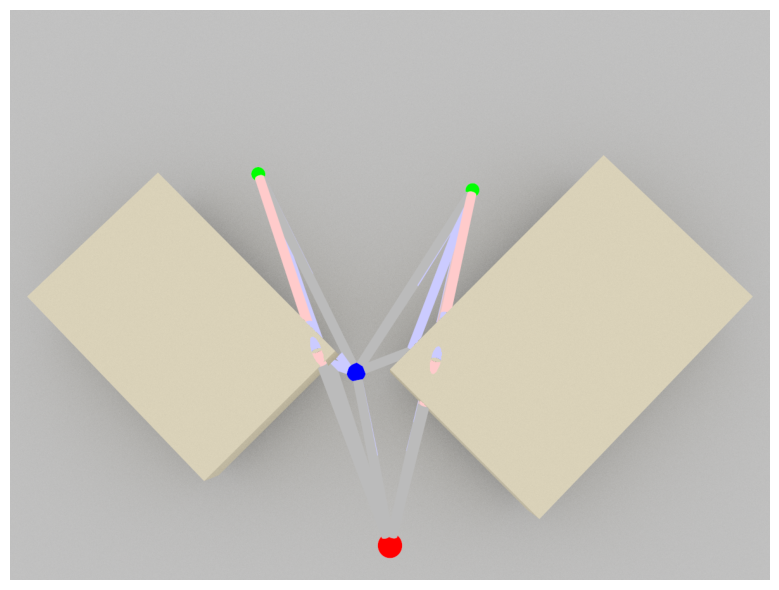

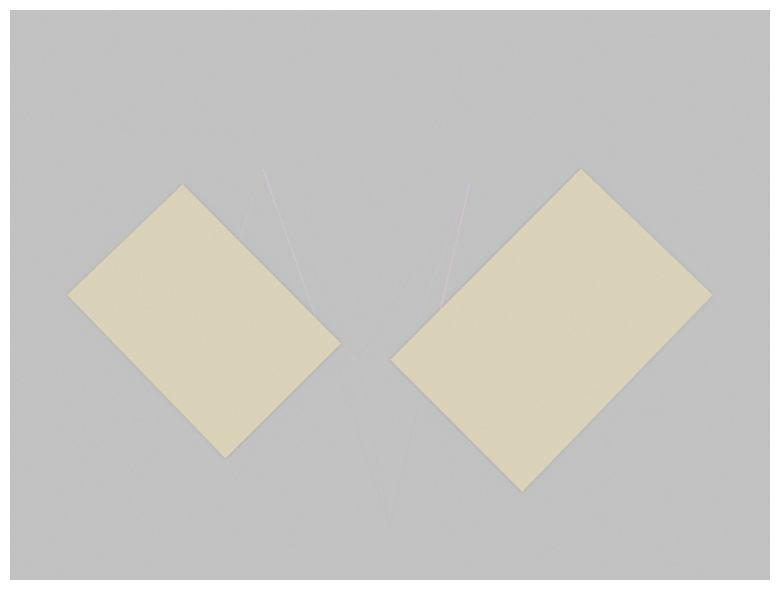

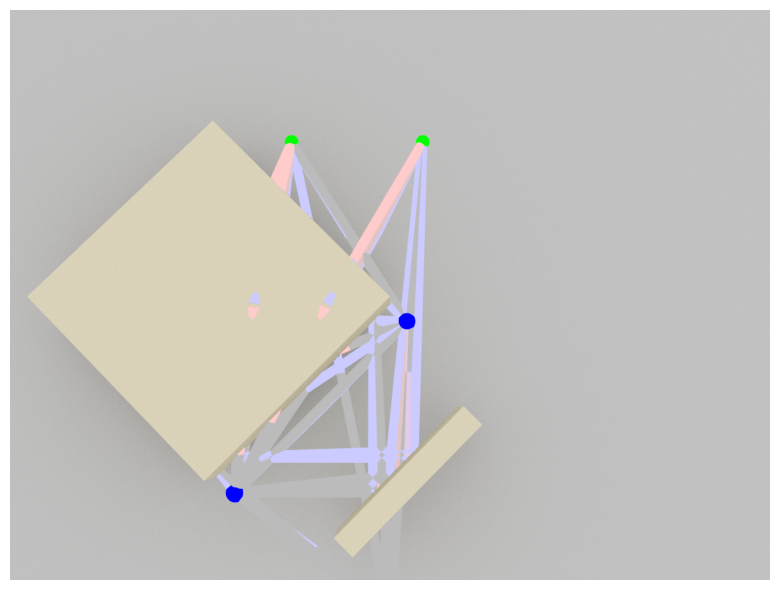

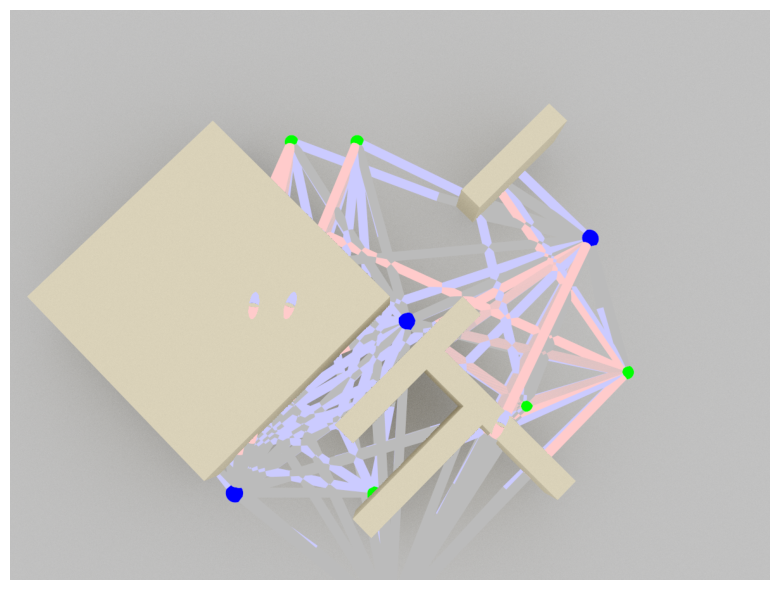

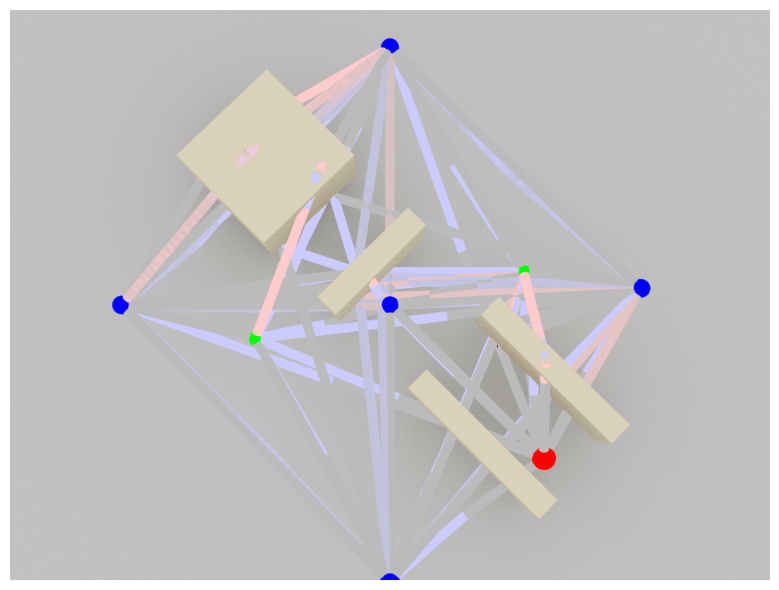

In [3]:
# Visualize all scenarios marked with calculate=True
should_do_all = True
if should_do_all:
    print("="*60)
    print("SCENARIO VISUALIZATION")
    print("="*60)

    scenarios_to_visualize = [s for s in situations if s['calculate']]
    print(f"\nFound {len(scenarios_to_visualize)} scenarios to visualize\n")

    for i, situation in enumerate(scenarios_to_visualize, 1):
        print(f"\n[{i}/{len(scenarios_to_visualize)}]")
        try:
            visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256)
            
        except Exception as e:
            print(f"❌ Error visualizing {situation['simulation_name']}: {e}")
            import traceback
            traceback.print_exc()

    print("\n" + "="*60)
    print("✓ All visualizations complete!")
    print("="*60)

## Visualize Individual Scenario

Use this cell to visualize a specific scenario by name with higher quality settings.


High-Quality Render (Single Reflection)

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 3, 'y': 3}
  RIS points (P1, P2, ...): [{'x': 7, 'y': 9}]
  Receivers (R1, R2, ...): [{'x': 16, 'y': 11}, {'x': 10, 'y': 18}]
  ✓ Added TX as transmitter at {'x': 3, 'y': 3}
  ✓ Added P1 as transmitter at {'x': 7, 'y': 9}
  ✓ Added P1_rx as receiver at {'x': 7, 'y': 9}
  ✓ Added R1 as receiver at {'x': 16, 'y': 11}
  ✓ Added R2 as receiver at {'x': 10, 'y': 18}

🔄 Running PathSolver with 2 transmitters and 3 receivers...
   Transmitters: TX, P1
   Receivers: P1_rx R1, R2
  ✅ PathSolver completed!
     Paths object type: <class 'sionna.rt.path_solvers.paths.Paths'>
     This includes all TX→*, P1→*, P2→*, etc. paths

🎨 Rendering scene with all paths...
✅ Complete



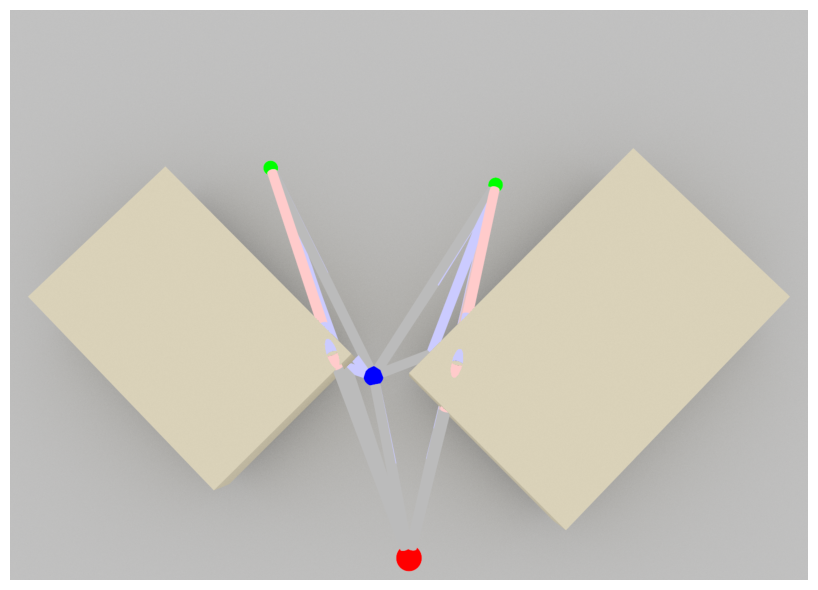

In [4]:
# Visualize a specific scenario by name
scenario_name = "Single Reflection"  # Change this to visualize different scenarios

situation = next((s for s in situations if s['simulation_name'] == scenario_name), None)

if situation:
    print(f"\nHigh-Quality Render ({scenario_name})")
    visualize_scenario(situation, render_resolution=(1400, 1000), num_samples=512)
else:
    print(f"Scenario '{scenario_name}' not found.")
    print("\nAvailable scenarios:")
    for s in situations:
        print(f"  - {s['simulation_name']}")

## Scene Information Summary

In [5]:
# Display summary table of all scenarios
summary_data = []
for situation in situations:
    summary_data.append({
        'Scenario': situation['simulation_name'],
        'Calculate': '✓' if situation['calculate'] else '✗',
        'Size (m)': f"{situation['width']}×{situation['height']}",
        'Resolution (m)': situation['resolution'],
        'Buildings': len(situation['buildings']),
        'RIS Points': len(situation['ris_points']),
        'Receivers': len(situation['receivers']),
    })

df = pd.DataFrame(summary_data)
print("\nScenario Summary:")
print("="*80)
display(df)


Scenario Summary:


,Scenario,Calculate,Size (m),Resolution (m),Buildings,RIS Points,Receivers
0,Single Reflection,✓,20×20,0.5,2,1,2
1,Single Reflection BIG,✓,2000×2000,50.0,2,1,2
2,Single Reflection - Clustered Receivers,✗,20×20,0.5,2,1,3
3,"RISs in series, only final",✓,20×20,0.5,2,2,2
4,RISs in series,✓,20×20,0.5,5,3,5
5,RISs in parallel,✓,20×20,0.5,4,5,3
